# Prediction of the 2026 American Midterm Elections using Data Science, Programming, and Statistics
The upcoming 2026 midterm elections in the United States is primed to be one of the most
divisive and consequential elections, with many important swing states that will change the
power balance of the United States. This project will attempt to predict the senate races for three
key swing states of Michigan, Maine, and Georgia and will utilise many of the skills I have
developed from the courses at AUP.

In [ ]:
from datetime import date
from IPython.display import Markdown, display

display(Markdown(f"## Week of {date.today():%B %d, %Y}"))

# Data Exploration

## Importing Libraries

In [1]:
#| output: true
#| echo: true
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
csv_path = "senate.csv"
data = pd.read_csv(csv_path)

ModuleNotFoundError: No module named 'pandas'

## Creating Main Dataset from CSV

In [ ]:
#| output: false
#| echo: true
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
### Renaming & Subsetting
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
## Recieves an array of all columns in the dataset
#print(data.columns)

data = data.rename(columns={ 'country':'Country', 'description':'Description', 'designation':'Designation', 'points':'Score', 'price':'Price', 'province':'Province', 'region_1':'Region 1', 'region_2':'Region 2', 
                            'taster_name':'Critic', 'taster_twitter_handle':'Twitter Handle', 'title':'Title', 'variety':'Variety', 'winery':'Winery'})

## Creating subset of our data to be the main dataframe
df = data[[
    'Country',
    #'Description', 'Designation',
    'Score', 'Price', 'Province',
    #'Region 1', 'Region 2',
    'Critic',
    #'Twitter Handle', 
    'Title', 'Variety', 'Winery']].copy()

In [ ]:
#| output: false
#| echo: false
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
## Describing the amount of rows by cols our dataframe has before dropping
df.shape

(129971, 8)

In [ ]:
#| output: false
#| echo: false
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
#### Cleaning Duplicated Values
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
## Locating all instances of rows that have equal values to another row
#df.loc[df.duplicated()]

## Analyzing a duplicated row to determine why there is a duplicated row in the dataframe
#df.query('Title == "Souverain 2010 Chardonnay (North Coast)"') 
## Results show every value is duplicated thus an error in the data set

## Subseting our main datafram by locating all rows that are 1st instance of there values thus no duplicated rows & resetting index
df = df.loc[~df.duplicated(subset=['Score','Price','Critic','Title','Winery'])] \
        .reset_index(drop=True).copy()
df.index += 1

## Describing the amount of rows by cols our dataframe has after dropping
#df.shape

In [ ]:
#| output: false
#| echo: false
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
#### Cleaning Missing Values
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
## Checking how many null values are in our dataframe
#main.isna().sum()

## Dropping rows with missing values in columns Country & Variety
## Red wine = dataset with unpriced wines
## White wine = dataset with priced wine
red_wine = df.dropna(subset=['Country','Variety'], inplace=False)
wht_wine = df.dropna(subset=['Country','Variety','Price'], inplace=False)
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
## Replacing null values in Critic with Unknown
red_wine.loc[:,('Critic')] = red_wine['Critic'].fillna('Unknown')
wht_wine.loc[:,('Critic')] = wht_wine['Critic'].fillna('Unknown')
## Verifying all rows in the price col have been replaced to Unknown
#red_wine.loc[red_wine['Critic'].isna()]

## Replacing null values in Price with Zero
red_wine.loc[:,('Price')] = red_wine['Price'].fillna(0)
## Verifying all rows in the price col have been set to zero
#red_wine.loc[red_wine['Price'].isna()]

## Reset the index
red_wine = red_wine.reset_index(drop=True).copy()
red_wine.index += 1

wht_wine = wht_wine.reset_index(drop=True).copy()
wht_wine.index += 1

In [ ]:
#| output: true
#| echo: false
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
## Displaying Cleaned dataset with unpriced wine
red_wine.head(119810)

,Country,Score,Price,Province,Critic,Title,Variety,Winery
1,Italy,87,0.0,Sicily & Sardinia,Kerin O’Keefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
2,Portugal,87,15.0,Douro,Roger Voss,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
3,US,87,14.0,Oregon,Paul Gregutt,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
4,US,87,13.0,Michigan,Alexander Peartree,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
5,US,87,65.0,Oregon,Paul Gregutt,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...,...,...
119806,Germany,90,28.0,Mosel,Anna Lee C. Iijima,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
119807,US,90,75.0,Oregon,Paul Gregutt,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
119808,France,90,30.0,Alsace,Roger Voss,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
119809,France,90,32.0,Alsace,Roger Voss,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


Text(0, 0.5, 'Count')

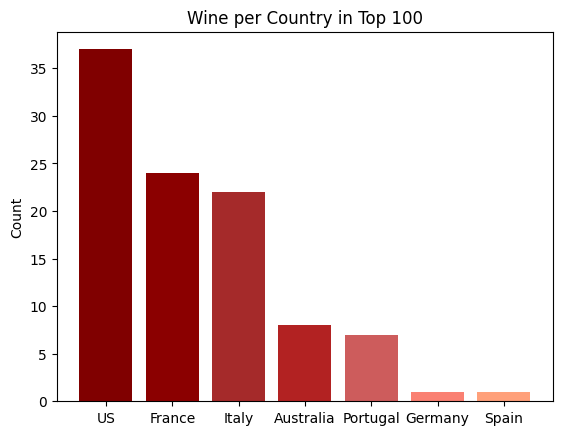

In [ ]:
#| output: true
#| echo: true
#| label: fig-1
#| fig-cap: "Wine per Country in top 100"
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
## Create a bar plot
fig1, ax1 = plt.subplots()

## Data
countries = ['US', 'France', 'Italy', 'Australia', 'Portugal', 'Germany', 'Spain']
wine_counts = [37, 24, 22, 8, 7, 1, 1]
colors = ['maroon', 'darkred', 'brown', 'firebrick', 'indianred', 'salmon', 'lightsalmon']

ax1.bar(countries, wine_counts, color=colors)

## Adding labels and title
ax1.set_title('Wine per Country in Top 100')
ax1.set_ylabel('Count')

# Conclusion

Through our analysis we found that the highest price did correlate with the highest wine ratings. However, we also found that the country of origin influenced a role in the quality of wine. France and Italy had the highest average ratings, while the US had the most wines in the top 100.

---

## References